### Importing & GPU check

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Confirming GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TF version:", tf.__version__)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.19.0


# TASK 1: Load and Normalize the Dataset

### Loading & Normalize MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add channel dim → (N, 28, 28, 1)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print("Train shape:", x_train.shape)
print("Test  shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28, 1)
Test  shape: (10000, 28, 28, 1)


# TASK 2: Autoencoder Experiments - Model Definition

### Standard Autoencoder (AE) builder

In [ ]:
LATENT_DIM = 2   # 2D latent space — easy to visualize

def build_autoencoder(filters):
    """
    filters : tuple of 3 ints, e.g. (128, 64, 32)
    Returns compiled (autoencoder, encoder, decoder) models.
    """
    f1, f2, f3 = filters

    # ---- Encoder ----
    enc_input = keras.Input(shape=(28, 28, 1), name="enc_input")
    x = layers.Conv2D(f1, 3, strides=2, padding="same", activation="relu")(enc_input)
    x = layers.Conv2D(f2, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(f3, 3, strides=2, padding="same", activation="relu")(x)
    shape_before_flatten = x.shape[1:]          # remember for decoder
    x = layers.Flatten()(x)
    latent = layers.Dense(LATENT_DIM, name="latent")(x)
    encoder = keras.Model(enc_input, latent, name="encoder")

    # ---- Decoder ----
    dec_input = keras.Input(shape=(LATENT_DIM,), name="dec_input")
    x = layers.Dense(np.prod(shape_before_flatten), activation="relu")(dec_input)
    x = layers.Reshape(shape_before_flatten)(x)
    x = layers.Conv2DTranspose(f3, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(f2, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(f1, 3, strides=2, padding="same", activation="relu")(x)
    # Crop back to 28×28 (strided convs give 32×32 for 28×28 input)
    x = layers.Cropping2D(cropping=((2, 2), (2, 2)))(x)
    dec_output = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    decoder = keras.Model(dec_input, dec_output, name="decoder")

    # ---- Full AE ----
    ae_output = decoder(encoder(enc_input))
    autoencoder = keras.Model(enc_input, ae_output, name="autoencoder")
    autoencoder.compile(optimizer="adam", loss="mse")
    return autoencoder, encoder, decoder

## TASK 2: Autoencoder Experiments - Training

### Train AE for all 3 filter configs & collect results

In [ ]:
ae_configs = [(128, 64, 32), (256, 128, 64), (512, 256, 128)]
ae_results = {}   # {config_str: {"history": ..., "encoder": ..., "ae": ...}}

for cfg in ae_configs:
    cfg_str = str(cfg)
    print(f"\n{'='*50}")
    print(f"Training AE | filters = {cfg_str}")
    print(f"{'='*50}")

    ae, enc, dec = build_autoencoder(cfg)
    ae.summary()

    history = ae.fit(
        x_train, x_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_test, x_test),
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1
    )
    ae_results[cfg_str] = {"history": history, "encoder": enc, "decoder": dec, "ae": ae}
    print(f"Best val_loss: {min(history.history['val_loss']):.5f}")


Training AE | filters = (128, 64, 32)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │        94,562 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       104,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,851 (776.76 KB)

 Trainable params: 198,851 (776.76 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │     1,484,162 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │     1,633,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,117,827 (11.89 MB)

 Trainable params: 3,117,827 (11.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 163ms/step - loss: 0.0771 - val_loss: 0.0461
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.0449 - val_loss: 0.0425
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0415 - val_loss: 0.0402
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0401 - val_loss: 0.0394
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0391 - val_loss: 0.0389
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0385 - val_loss: 0.0385
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0379 - val_loss: 0.0381
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0376 - val_loss: 0.0378
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0371 - val_loss: 0.0378
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0369 - val_loss: 0.0373
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.0366 - val_loss: 0.0373
Epoch 12/20
469/469

## TASK 2: Autoencoder Experiments - Analysis

### Plotting AE training curves (loss comparison)

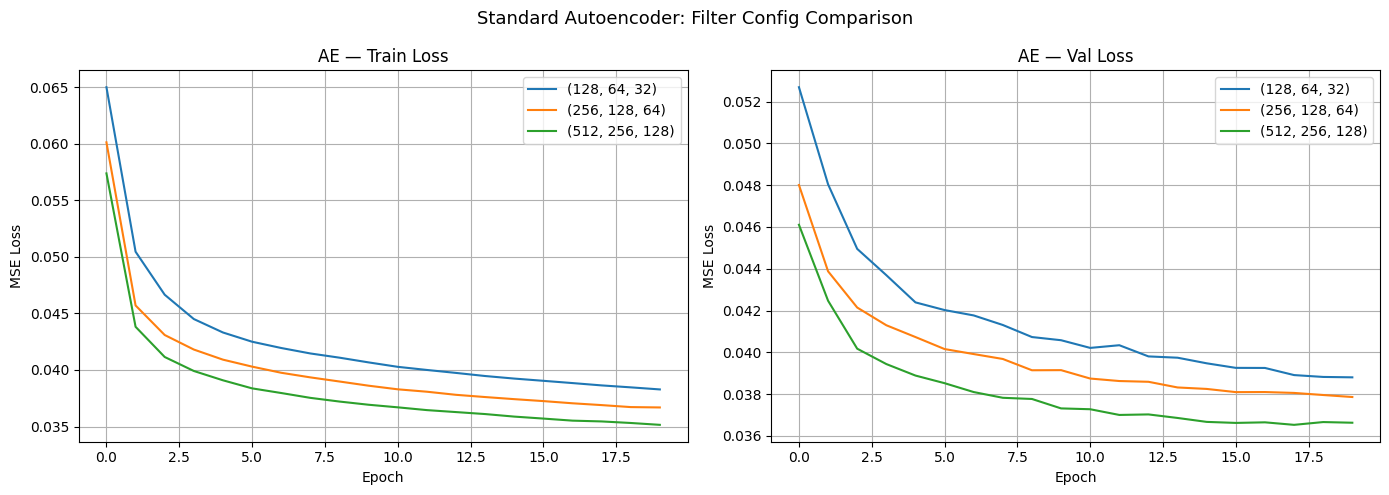

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cfg_str, res in ae_results.items():
    h = res["history"].history
    axes[0].plot(h["loss"],     label=cfg_str)
    axes[1].plot(h["val_loss"], label=cfg_str)

for ax, title in zip(axes, ["Train Loss", "Val Loss"]):
    ax.set_title(f"AE — {title}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(True)
plt.suptitle("Standard Autoencoder: Filter Config Comparison", fontsize=13)
plt.tight_layout(); plt.show()

### Obersvation
As the number of filters increases from (128, 64, 32) to (512, 256, 128), the training as well as the validation loss decreases. This shows that the models using more filters can identify more complex features of the MNIST digits and thus perform better in reconstruction.

As the (512, 256, 128) configuration has the lowest loss among the epochs, this shows that the higher the model capacity, the better the reconstruction performance, although at the cost of increased computation.

### Visualising AE reconstructions for each config

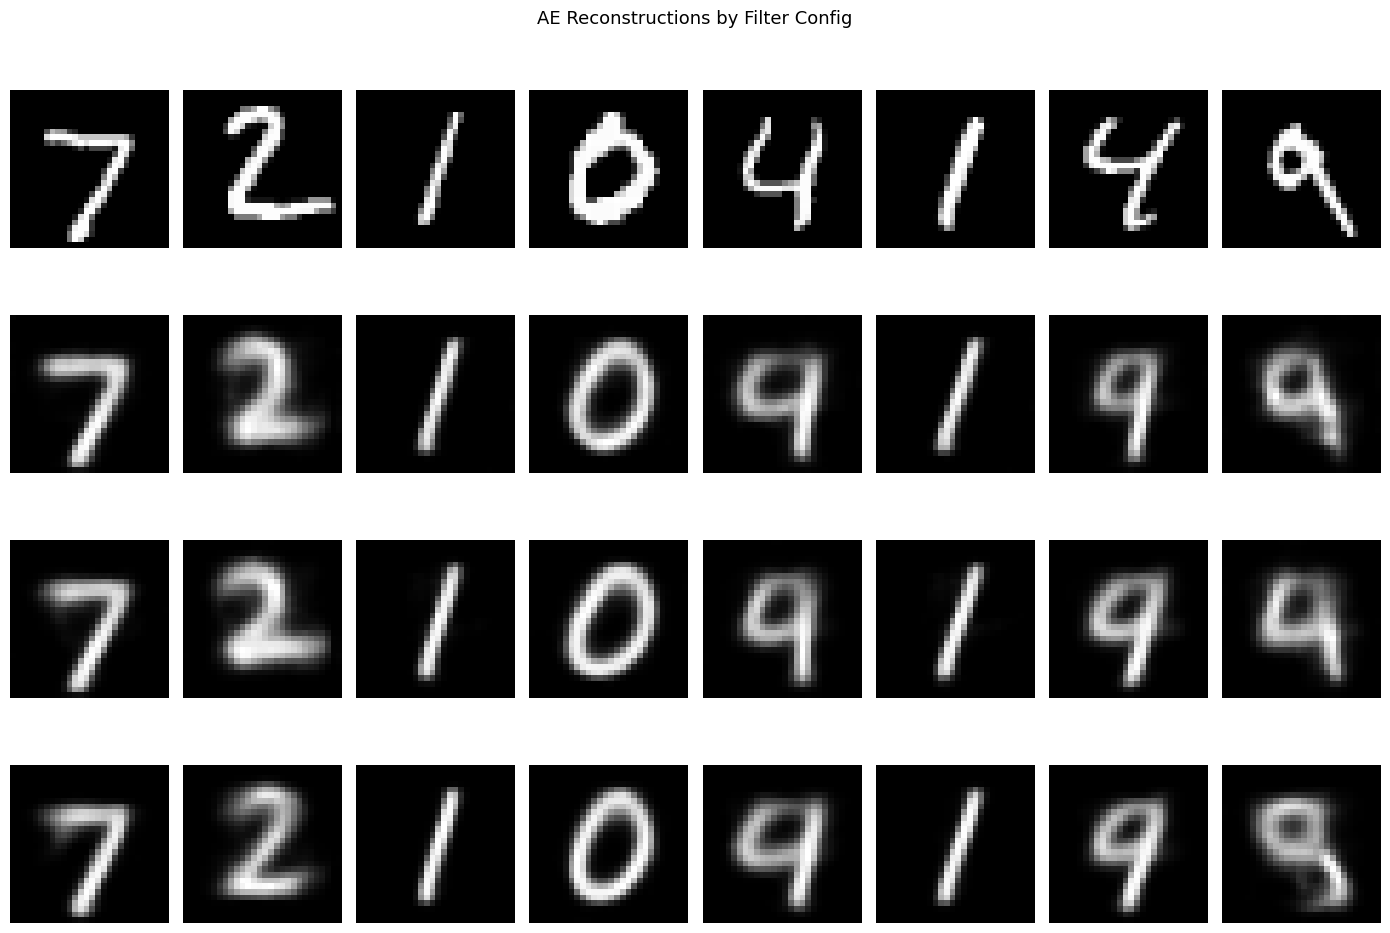

In [ ]:
n_show = 8
fig, axes = plt.subplots(len(ae_configs) + 1, n_show, figsize=(14, 2.5 * (len(ae_configs) + 1)))

# Row 0: originals
for i in range(n_show):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)

# Rows 1-3: reconstructions per config
for row, cfg in enumerate(ae_configs, start=1):
    ae = ae_results[str(cfg)]["ae"]
    recons = ae.predict(x_test[:n_show], verbose=0)
    for i in range(n_show):
        axes[row, i].imshow(recons[i].squeeze(), cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(str(cfg), fontsize=8)

plt.suptitle("AE Reconstructions by Filter Config", fontsize=13)
plt.tight_layout(); plt.show()

## TASK 2: Autoencoder Experiments - Latent Space Analysis

### Plotting AE latent space (2D scatter, color = digit)

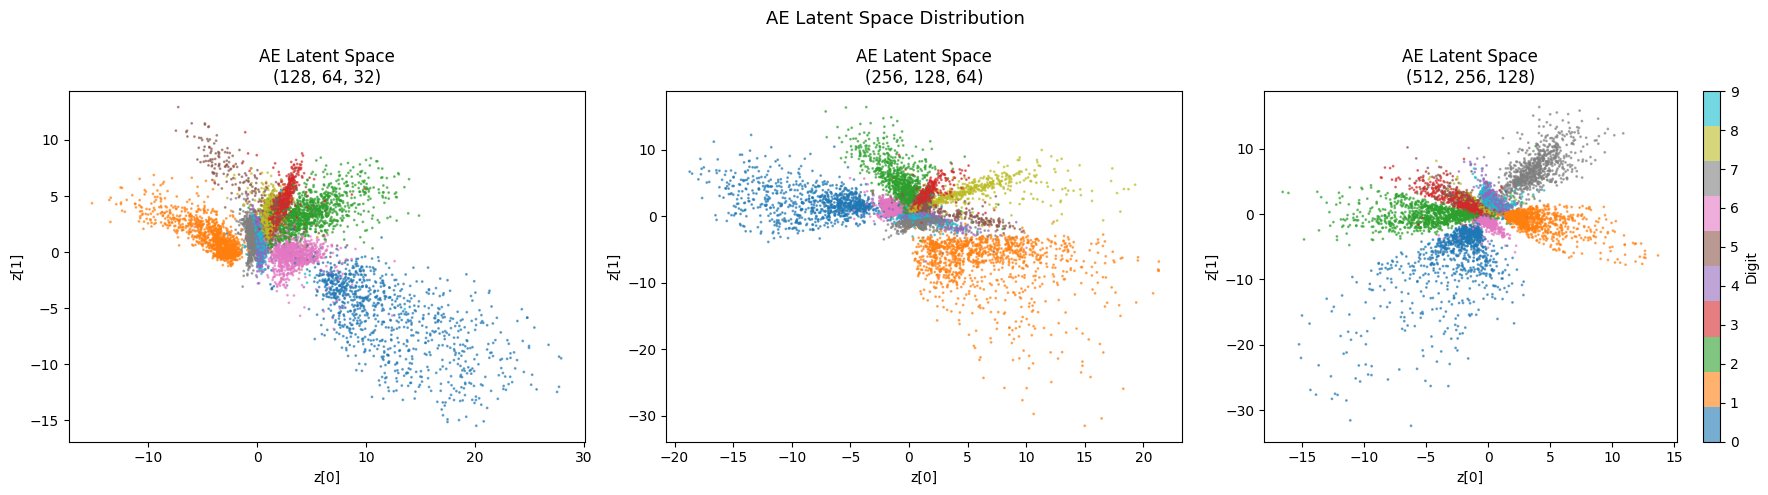

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, ae_configs):
    enc = ae_results[str(cfg)]["encoder"]
    z   = enc.predict(x_test, verbose=0)
    sc  = ax.scatter(z[:, 0], z[:, 1], c=y_test, cmap="tab10", s=1, alpha=0.6)
    ax.set_title(f"AE Latent Space\n{cfg}"); ax.set_xlabel("z[0]"); ax.set_ylabel("z[1]")
plt.colorbar(sc, ax=axes[-1], label="Digit")
plt.suptitle("AE Latent Space Distribution", fontsize=13)
plt.tight_layout(); plt.show()

### Observation

From the above latent space plot, we can observe that the autoencoder has learned meaningful representations because the clusters are forming based on the digits that are similar in shape. This implies that the autoencoder has learned the significant structural features of the MNIST digits.

As we increase the number of filters from (128, 64, 32) to (512, 256, 128), we can observe that the clusters are more structured, which implies that the autoencoder has learned more discriminative representations.

# TASK 3: Variational Autoencoder Experiments — Setup

### VAE: Sampling layer

In [ ]:
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + eps * exp(0.5 * log_var)"""
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

## TASK 3: Variational Autoencoder Experiments — Training

### Training VAE for all 3 filter configs

In [ ]:
def build_vae(filters):
    """
    filters : tuple of 3 ints
    Returns (vae_model, encoder_model, decoder_model)
    The vae_model has a custom train_step with ELBO loss.
    """
    f1, f2, f3 = filters

    # ---- Encoder ----
    enc_input = keras.Input(shape=(28, 28, 1), name="enc_input")
    x = layers.Conv2D(f1, 3, strides=2, padding="same", activation="relu")(enc_input)
    x = layers.Conv2D(f2, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(f3, 3, strides=2, padding="same", activation="relu")(x)
    shape_before_flatten = x.shape[1:]
    x = layers.Flatten()(x)
    mu      = layers.Dense(LATENT_DIM, name="mu")(x)
    log_var = layers.Dense(LATENT_DIM, name="log_var")(x)
    z       = Sampling()([mu, log_var])
    encoder = keras.Model(enc_input, [mu, log_var, z], name="vae_encoder")

    # ---- Decoder (same as AE decoder) ----
    dec_input = keras.Input(shape=(LATENT_DIM,), name="dec_input")
    x = layers.Dense(np.prod(shape_before_flatten), activation="relu")(dec_input)
    x = layers.Reshape(shape_before_flatten)(x)
    x = layers.Conv2DTranspose(f3, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(f2, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(f1, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Cropping2D(cropping=((2, 2), (2, 2)))(x)
    dec_output = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    decoder = keras.Model(dec_input, dec_output, name="vae_decoder")

    # ---- VAE with custom ELBO loss ----
    class VAE(keras.Model):
        def __init__(self, enc, dec, **kwargs):
            super().__init__(**kwargs)
            self.encoder = enc
            self.decoder = dec
            # Trackers for logging
            self.total_loss_tracker   = keras.metrics.Mean(name="loss")
            self.recon_loss_tracker   = keras.metrics.Mean(name="recon_loss")
            self.kl_loss_tracker      = keras.metrics.Mean(name="kl_loss")

        @property
        def metrics(self):
            return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

        def train_step(self, data):
            with tf.GradientTape() as tape:
                mu, log_var, z = self.encoder(data)
                x_recon = self.decoder(z)
                # Reconstruction loss: binary cross-entropy per pixel, summed over pixels
                recon_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        keras.losses.binary_crossentropy(data, x_recon),
                        axis=(1, 2)
                    )
                )
                # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
                )
                total_loss = recon_loss + kl_loss

            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.recon_loss_tracker.update_state(recon_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {m.name: m.result() for m in self.metrics}

        def test_step(self, data):
            mu, log_var, z = self.encoder(data)
            x_recon = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, x_recon), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss
            self.total_loss_tracker.update_state(total_loss)
            self.recon_loss_tracker.update_state(recon_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {m.name: m.result() for m in self.metrics}

    vae = VAE(encoder, decoder, name=f"vae_{'_'.join(map(str, filters))}")
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae, encoder, decoder

## TASK 3: Variational Autoencoder Experiments - Training

### Training VAE for all 3 filter configs

In [ ]:
vae_configs = [(128, 64, 32), (256, 128, 64), (512, 256, 128)]
vae_results = {}

for cfg in vae_configs:
    cfg_str = str(cfg)
    print(f"\n{'='*50}")
    print(f"Training VAE | filters = {cfg_str}")
    print(f"{'='*50}")

    vae, enc, dec = build_vae(cfg)

    history = vae.fit(
        x_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_test,),
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
        verbose=1
    )
    vae_results[cfg_str] = {"history": history, "encoder": enc, "decoder": dec, "vae": vae}
    print(f"Best val_loss: {min(history.history['val_loss']):.2f}")


Training VAE | filters = (128, 64, 32)
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - kl_loss: 1.6721 - loss: 260.8299 - recon_loss: 259.1578 - val_kl_loss: 4.7411 - val_loss: 167.9027 - val_recon_loss: 163.1616
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - kl_loss: 4.9094 - loss: 164.6790 - recon_loss: 159.7697 - val_kl_loss: 5.2610 - val_loss: 159.8667 - val_recon_loss: 154.6057
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - kl_loss: 5.2738 - loss: 159.3721 - recon_loss: 154.0982 - val_kl_loss: 5.5072 - val_loss: 156.3207 - val_recon_loss: 150.8135
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.5300 - loss: 156.2356 - recon_loss: 150.7057 - val_kl_loss: 5.6278 - val_loss: 154.5450 - val_recon_loss: 148.9172
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 5.7013 - loss: 154.5527 - recon_loss: 148.8514 - val_kl_loss: 5.7670 - val_loss: 153.4227 - val_recon_loss: 147.6557
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step -

## TASK 3: Variational Autoencoder Experiments - Analysis

### Plotting VAE training curves

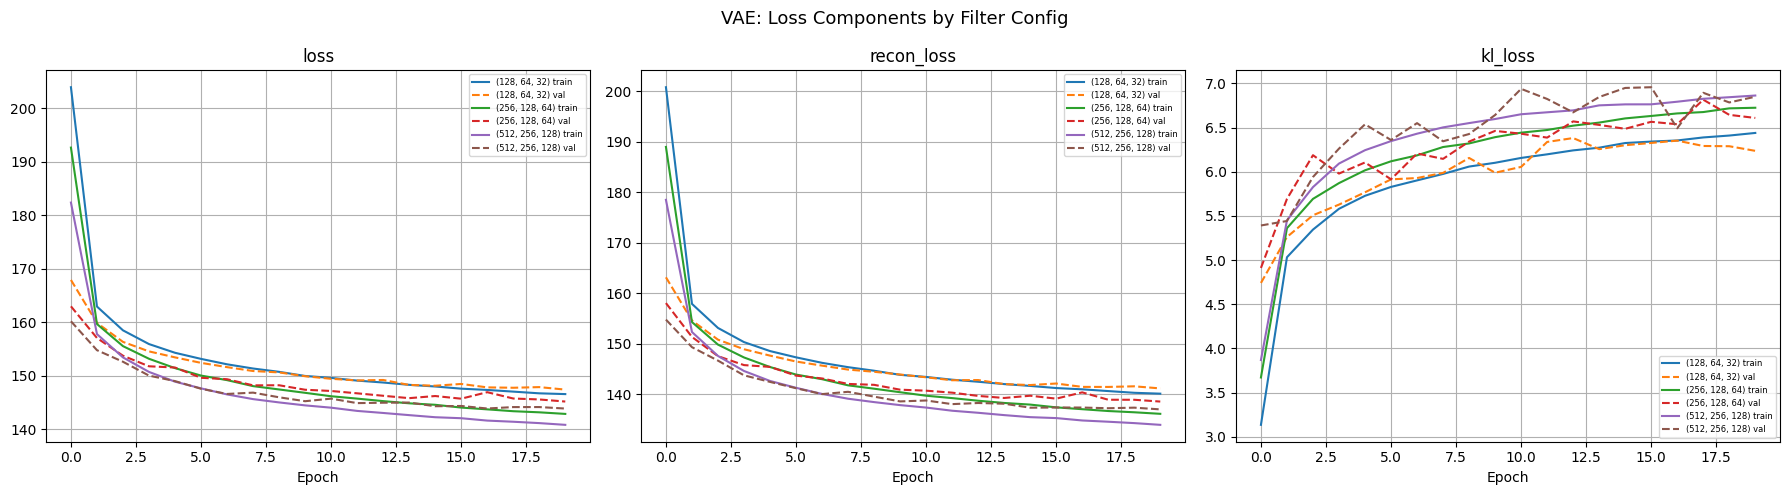

In [ ]:
metrics_to_plot = ["loss", "recon_loss", "kl_loss"]
val_metrics     = ["val_loss", "val_recon_loss", "val_kl_loss"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, met, vmet in zip(axes, metrics_to_plot, val_metrics):
    for cfg_str, res in vae_results.items():
        h = res["history"].history
        ax.plot(h[met],  label=f"{cfg_str} train")
        ax.plot(h[vmet], linestyle="--", label=f"{cfg_str} val")
    ax.set_title(met); ax.set_xlabel("Epoch"); ax.legend(fontsize=6); ax.grid(True)
plt.suptitle("VAE: Loss Components by Filter Config", fontsize=13)
plt.tight_layout(); plt.show()

### Observation
The total loss of VAE is decreasing steadily throughout the training process, indicating that the model is effectively learning the representation and reconstructing the input images.

The reconstruction loss is decreasing over time, indicating that the reconstruction is becoming better as the model is able to effectively learn the features of the digit using the VAE.

The KL divergence is increasing steadily throughout the training process, which is natural because the VAE is designed to produce a normal distribution in the latent space and hence a smoother and more structured representation is preferred.

Similar to the autoencoder experiment, the configuration (512, 256, 128) is able to achieve a slightly lower reconstruction loss than the other configurations, indicating that a higher capacity model is able to achieve better learning of the representation.

### VAE reconstructions (visual quality check)

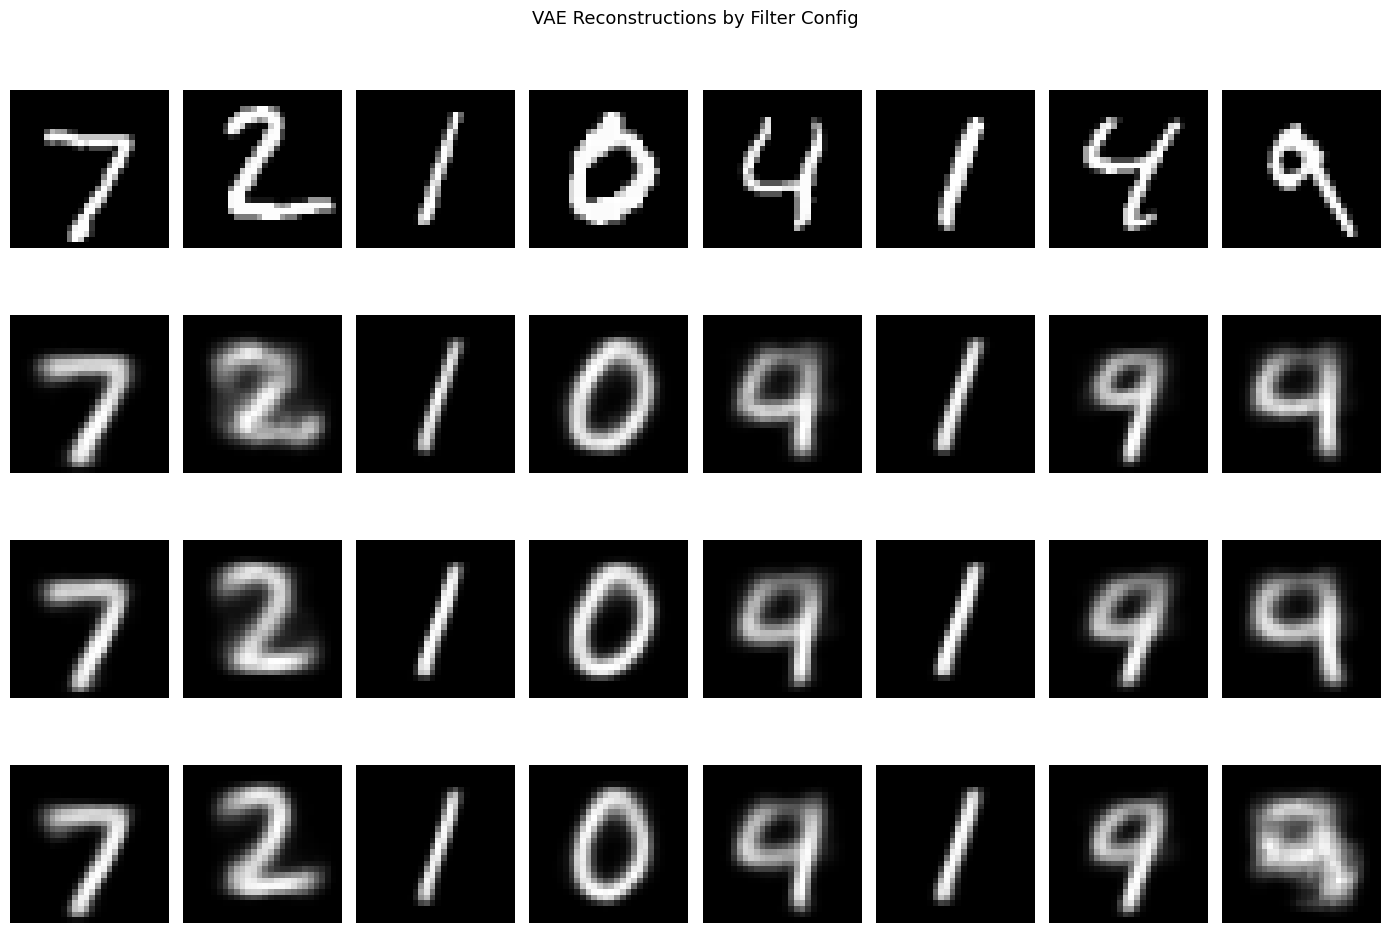

In [ ]:
n_show = 8
fig, axes = plt.subplots(len(vae_configs) + 1, n_show, figsize=(14, 2.5 * (len(vae_configs) + 1)))

for i in range(n_show):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)

for row, cfg in enumerate(vae_configs, start=1):
    enc = vae_results[str(cfg)]["encoder"]
    dec = vae_results[str(cfg)]["decoder"]
    mu, _, _ = enc.predict(x_test[:n_show], verbose=0)   # use mu (mean) for clean recon
    recons   = dec.predict(mu, verbose=0)
    for i in range(n_show):
        axes[row, i].imshow(recons[i].squeeze(), cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(str(cfg), fontsize=8)

plt.suptitle("VAE Reconstructions by Filter Config", fontsize=13)
plt.tight_layout(); plt.show()

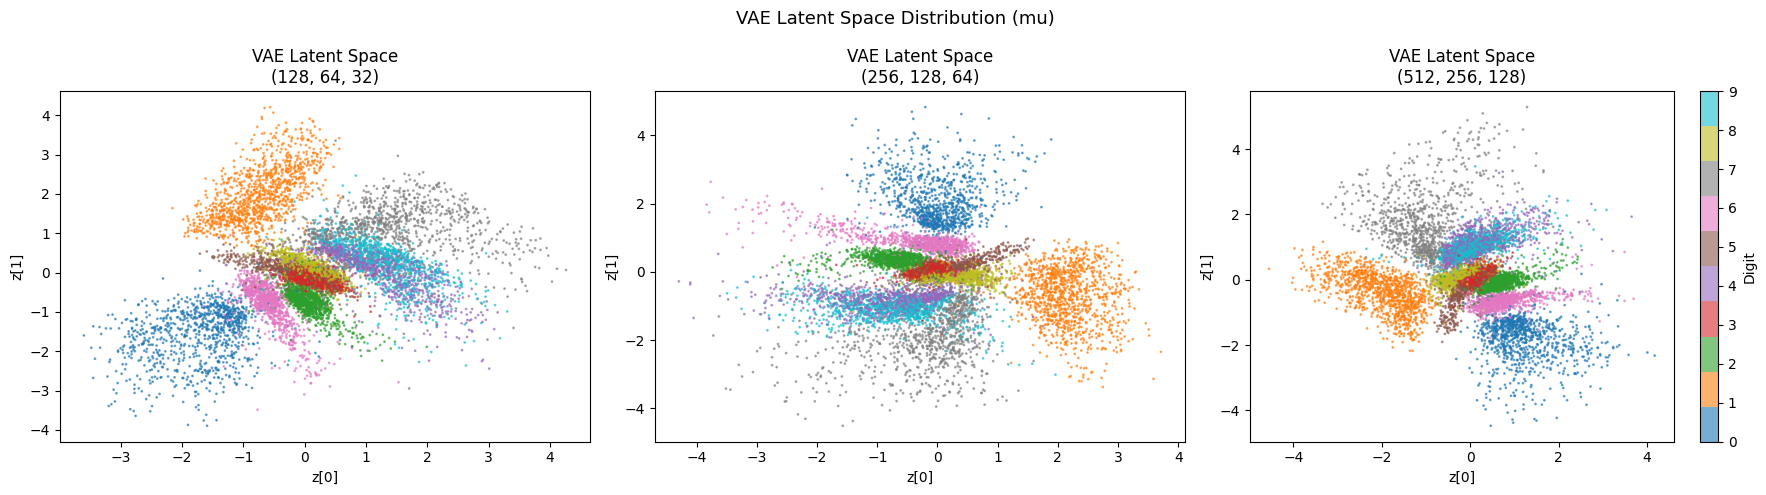

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, vae_configs):
    enc = vae_results[str(cfg)]["encoder"]
    mu, _, _ = enc.predict(x_test, verbose=0)
    sc = ax.scatter(mu[:, 0], mu[:, 1], c=y_test, cmap="tab10", s=1, alpha=0.6)
    ax.set_title(f"VAE Latent Space\n{cfg}"); ax.set_xlabel("z[0]"); ax.set_ylabel("z[1]")
plt.colorbar(sc, ax=axes[-1], label="Digit")
plt.suptitle("VAE Latent Space Distribution (mu)", fontsize=13)
plt.tight_layout(); plt.show()

### Observation
The VAE’s latent space has denser and smoother clusters compared to the autoencoder’s. This is because the KL divergence regularizes the latent space to be normally distributed.

Similar shapes of digits are located closer to each other, which means the VAE has successfully learned the semantic features of the MNIST dataset.

The model with different configurations of filters has the model with the configuration of (512, 256, 128) have slightly clearer clusters. This means the larger the model, the clearer the features.

In [ ]:
print(f"\n{'Config':<20} {'AE val_loss':>15} {'VAE val_loss':>15}")
print("-" * 52)
for cfg in ae_configs:
    cfg_str = str(cfg)
    ae_loss  = min(ae_results[cfg_str]["history"].history["val_loss"])
    vae_loss = min(vae_results[cfg_str]["history"].history["val_loss"])
    print(f"{cfg_str:<20} {ae_loss:>15.5f} {vae_loss:>15.2f}")


Config                   AE val_loss    VAE val_loss
----------------------------------------------------
(128, 64, 32)                0.03880          147.40
(256, 128, 64)               0.03786          145.17
(512, 256, 128)              0.03653          143.86


# TASK 4: Morphing Between Images - Uses the best VAE (512, 256, 128)


### Morph from digit "0" → "8"

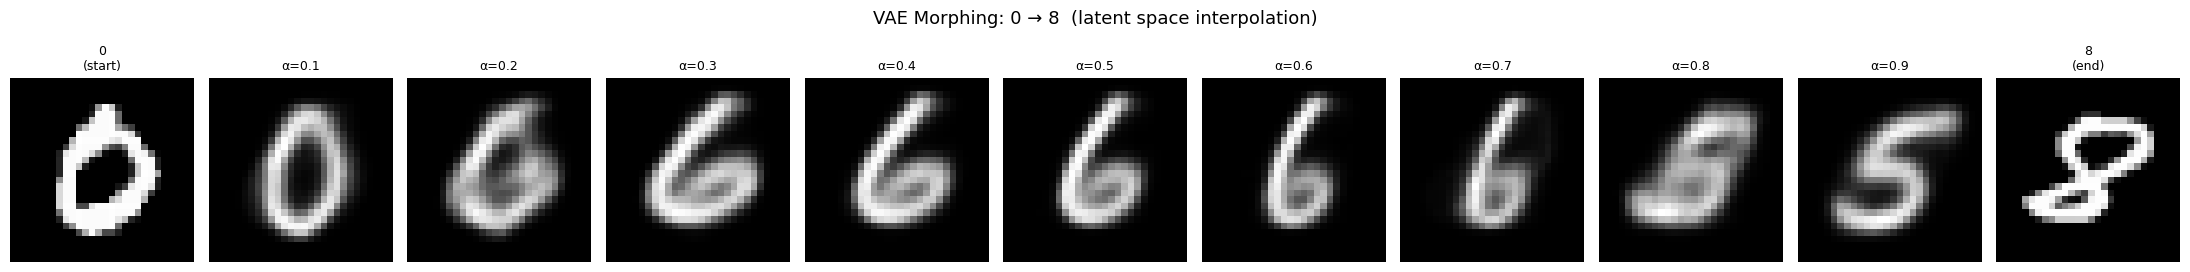

In [ ]:
BEST_CFG = str((512, 256, 128))
enc = vae_results[BEST_CFG]["encoder"]
dec = vae_results[BEST_CFG]["decoder"]

# Pick one clean example of "0" and "8" from test set
idx_0 = np.where(y_test == 0)[0][0]
idx_8 = np.where(y_test == 8)[0][0]

img_0 = x_test[idx_0:idx_0+1]   # shape (1, 28, 28, 1)
img_8 = x_test[idx_8:idx_8+1]

# Encode → get latent means (no noise for clean morphing)
mu_0, _, _ = enc.predict(img_0, verbose=0)   # shape (1, LATENT_DIM)
mu_8, _, _ = enc.predict(img_8, verbose=0)

# Interpolate: z = (1-alpha)*mu_0 + alpha*mu_8
alphas = np.arange(0.1, 1.0, 0.1)           # 0.1, 0.2, ..., 0.9
morph_images = []
for a in alphas:
    z_interp = (1 - a) * mu_0 + a * mu_8
    img_interp = dec.predict(z_interp, verbose=0)
    morph_images.append(img_interp[0].squeeze())

# Plot: original "0", 9 morphs, original "8"  (total 11 images)
all_images  = [img_0[0].squeeze()] + morph_images + [img_8[0].squeeze()]
all_labels  = ["0\n(start)"] + [f"α={a:.1f}" for a in alphas] + ["8\n(end)"]

fig, axes = plt.subplots(1, 11, figsize=(22, 3))
for ax, img, lbl in zip(axes, all_images, all_labels):
    ax.imshow(img, cmap="gray")
    ax.set_title(lbl, fontsize=9)
    ax.axis("off")
plt.suptitle("VAE Morphing: 0 → 8  (latent space interpolation)", fontsize=13)
plt.tight_layout(); plt.show()

# Observations

1. Effect of Increasing the Number of Filters on Reconstruction

With an increase in the number of filters used by the convolutional layers, i.e., from (128, 64, 32) to (512, 256, 128), it was observed that the quality of the reconstructed images was better. The models with a higher number of filters were able to capture the finer features of the digits, hence providing a lower reconstruction loss with clear images.

2. Structure of the Latent Space

The structure of the latent space obtained by the Variational Autoencoder was observed to be smoother compared to the autoencoder. This is expected since the VAE has an additional constraint of KL divergence. The KL divergence constraint ensures the latent space follows a normal distribution. Hence, the vectors obtained by the VAE are closer to each other compared to the autoencoder.

3. Comparison of Autoencoder with Variational Autoencoder

The autoencoder model was observed to provide a slightly lower reconstruction loss compared to the VAE model. This is because the autoencoder is only concerned with the reconstruction of the input images. Hence, it is able to provide a low reconstruction loss. The VAE has to compromise between the two losses; hence, it provides a relatively higher loss.


4. Latent Space Interpolation (0 → 8)

The interpolation between the latent representation of digits 0 and 8 resulted in a smooth transformation between the two digits. The transformation was observed to change gradually, thus showing that the VAE learned a continuous representation of the data in the latent space.

5. Impact of Model Capacity

The increased capacity of the models (i.e., the number of filters) resulted in an improvement in reconstruction but also in increased complexity in the models. This shows that there is a trade-off between the performance and complexity of deep models.